# Import The Important Libraries

In [1]:
import numpy as np

import matplotlib
import matplotlib.pyplot as plt

import seaborn as sns

import pandas as pd

import sklearn

import imblearn

import xgboost


print(np.__version__)
print(matplotlib.__version__)
print(sns.__version__)
print(pd.__version__)
print(sklearn.__version__)
print(imblearn.__version__)
print(xgboost.__version__)

2.1.3
3.10.0
0.13.2
2.2.3
1.6.1
0.14.2
3.4.1


# Reading Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/NSL-KDD/kdd_train.csv')
df = pd.concat([df, pd.read_csv('/content/drive/MyDrive/Colab Notebooks/NSL-KDD/kdd_test.csv')], axis=0, ignore_index=True)
print("Done")

Mounted at /content/drive
Done


In [3]:
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,labels
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


# Understanding Features

## Basic connection features
- duration --> Duration of the network connection, usually in seconds.
- protocol_type --> Network protocol used, e.g. tcp, udp, icmp.
- service --> Network service/destination service, e.g. http, ftp, smtp, telnet.
- flag --> Status/condition of the TCP connection, e.g. SF (normal establishment), S0 (connection attempt without response), REJ (rejected).
- src_bytes --> Number of bytes sent from source → destination.
- dst_bytes --> Number of bytes sent from destination → source.
- land --> Whether source and destination IP/port are the same. 1 = yes, 0 = no. This can indicate a LAND attack.
## Error and unusual packet features
- wrong_fragment --> Number of incorrectly fragmented IP packets.
- urgent --> Number of urgent packets/urgent data indicators.
- hot --> Number of "hot" indicators, representing suspicious or sensitive <b>activities</b> such as accessing certain system resources.
- num_failed_logins -->	Number of failed login attempts.
- logged_in --> Whether the connection successfully logged in. 1 = yes, 0 = no.
- num_compromised --> Number of compromised conditions detected during the connection.
- root_shell --> Whether a root shell was obtained. 1 = yes, 0 = no.
- su_attempted --> Whether there was an attempt to use su to become another user/root.
- num_root --> Number of times root/administrator access was obtained.
- num_file_creations --> Number of files created during the connection/session.
- num_shells --> Number of shell prompts/shell sessions opened.
- num_access_files --> Number of operations involving <b>access</b> to access-control files.
- num_outbound_cmds --> Number of outbound commands (from the client → server) in an FTP session. In this dataset it is generally constant/zero.
- is_host_login --> Whether the login was to the host itself.
- is_guest_login --> Whether the login was performed as a guest user.
## Connection-count features
- count --> Number of connections to the same destination host within the recent time window.
- srv_count --> Number of connections to the same destination service within the recent time window.
## Connection error rates
- serror_rate --> Percentage of connections with SYN errors.
- srv_serror_rate --> Percentage of connections to the same service with SYN errors.
- rerror_rate --> Percentage of connections with REJ/reset-related errors (REJ and reset here related to a TCP connection).
- srv_rerror_rate --> Percentage of connections to the same service with rejection/reset errors.
## Service/connection distribution features
- same_srv_rate --> Percentage of recent connections that accessed the same service.
- diff_srv_rate --> Percentage of recent connections that accessed different services.
- srv_diff_host_rate --> Percentage of connections to the same service that were made to different hosts.
## Destination-host features
- dst_host_count --> Number of connections to the same destination host.
- dst_host_srv_count --> Number of connections to the same destination host and service.
- dst_host_same_srv_rate --> Percentage of connections to the same destination host using the same service.
- dst_host_diff_srv_rate --> Percentage of connections to the same destination host using different services.
- dst_host_same_src_port_rate --> Percentage of connections to same the destination host using the same source port.
- dst_host_srv_diff_host_rate --> Percentage of connections to the same service on the same destination host that came from different source hosts.
## Destination-host error rates
- dst_host_serror_rate --> Percentage of connections to the same destination host having SYN errors.
- dst_host_srv_serror_rate --> Percentage of connections to the same destination service having SYN errors.
- dst_host_rerror_rate --> Percentage of connections to the same destination host having rejection/reset errors.
- dst_host_srv_rerror_rate --> Percentage of connections to the same destination service having rejection/reset errors.
## Target
- labels --> This is not a feature. It is the class/target that you want your ML model to predict.
    - Normal
    - DoS --> back, land, neptune, pod, smurf, teardrop, apache2, udpstorm, processtable, mailbomb
    - Probe -->	ipsweep, nmap, portsweep, satan, mscan, saint
    - R2L --> ftp_write, guess_passwd, imap, multihop, phf, warezclient, warezmaster, sendmail, named, snmpgetattack, snmpguess, warezmaster*
    - U2R --> buffer_overflow, loadmodule, perl, rootkit, ps

# Preprocessing

## Create a new column to classificate normal Vs. attack

In [4]:
df.loc[df['labels'] == 'normal', 'label'] = 0
df.loc[df['labels'] != 'normal', 'label'] = 1
print(df['label'].value_counts())

label
0.0    78588
1.0    69929
Name: count, dtype: int64


## Create a new column to classificate the major attack categories

In [5]:
# Add new column with major_cat
DoS = ['back', 'land', 'neptune', 'pod', 'smurf', 'teardrop',
       'apache2', 'udpstorm', 'processtable', 'mailbomb']
Probe = ['ipsweep', 'nmap', 'portsweep', 'satan', 'mscan', 'saint']
R2L = ['ftp_write', 'guess_passwd', 'imap', 'multihop', 'phf',
       'warezclient', 'warezmaster', 'sendmail', 'named',
       'snmpgetattack', 'snmpguess', 'spy', 'httptunnel', 'xlock', 'xsnoop']
U2R = ['buffer_overflow', 'loadmodule', 'perl', 'rootkit', 'ps', 'xterm']

def map_to_category(label):
    if label == 'normal':
        return 'normal'
    elif label in DoS:
        return 'Dos'
    elif label in Probe:
        return 'Probe'
    elif label in R2L:
        return 'R2L'
    elif label in U2R:
        return 'U2R'
df['major_cat'] = df['labels'].apply(map_to_category)
print(df.groupby('major_cat')['labels'].value_counts())

major_cat  labels         
Dos        neptune            47868
           smurf               3186
           back                1183
           teardrop             996
           pod                  236
           apache2              228
           processtable         211
           mailbomb              94
           land                  20
Probe      satan               4331
           ipsweep             4078
           portsweep           3302
           nmap                1699
           mscan                310
           saint                 93
R2L        warezclient          997
           guess_passwd         464
           warezmaster          299
           snmpguess             99
           snmpgetattack         43
           httptunnel            41
           multihop              16
           imap                  13
           ftp_write             10
           sendmail               8
           phf                    5
           xlock                  4
 

# Exploratory Data Analysis

## Dataset overview
- How many rows and columns are in the dataset?
- What are the data types of all columns?
- Are there missing values?
- Are there duplicated rows?
- Which columns have constant values?
- Which columns have very few unique values?

In [6]:
rows = df.shape[0]
print(f"Total number of rows: {rows}")
columns = df.shape[1]
print(f"Total number of columns: {columns}")
missging_values = df.isna().any().any()
print(f"is there any missing values? {missging_values}")
duplicate_values = df.duplicated().any()
print(f"is there any duplicate values? {duplicate_values}")
constant_values = df.columns[df.nunique() == 1]
print(f"Which columns have constant values: {constant_values.values[0]}")
unique_values = df.nunique()
least_5 = unique_values.nsmallest(5)
print(f"the columns that have very few unique value:")
print(least_5)

Total number of rows: 148517
Total number of columns: 44
is there any missing values? False
is there any duplicate values? True
Which columns have constant values: num_outbound_cmds
the columns that have very few unique value:
num_outbound_cmds    1
land                 2
logged_in            2
root_shell           2
is_host_login        2
dtype: int64


### handling the duplicated rows and constant features

In [7]:
df = df.drop_duplicates()
df.shape

(132726, 44)

In [8]:
df = df.drop(columns='num_outbound_cmds')
df.shape

(132726, 43)

## Target / attack distribution
- How many Normal samples are there?
- How many Attack samples are there?
- How many different attack labels exist?
- Which attack is the most common?
- Which attack is the rarest?
- What percentage of the dataset is Normal vs Attack?
- How imbalanced are the individual attack classes?

In [9]:
rows = df.shape[0]
normal_samples = df[df['labels'] == 'normal']
print(f"the normal samples counts: {normal_samples.shape[0]}")
attacks_samples = df[df['labels'] != 'normal']
print(f"the attack samples counts: {attacks_samples.shape[0]}")
attack_categories = df[df['labels'] != 'normal']['labels'].value_counts()
num_attack_categories = len(attack_categories)
print(f"the attack categories counts: {num_attack_categories}")
most_common_attack = [attack_categories.max(), attack_categories.idxmax()]
print(f"the most common attack: {most_common_attack[1]}")
rarest_attack = [attack_categories.min(), attack_categories.idxmin()]
print(f"the rarest attack: {rarest_attack[1]}")
imbalanced_ratio_attacks = most_common_attack[0]//rarest_attack[0]
print(f"the imbalanced ratio: {imbalanced_ratio_attacks}:1")
print(f"the normal samples: {normal_samples.shape[0]/rows*100:0.2f}%")
print(f"the attack samples: {attacks_samples.shape[0]/rows*100:0.2f}%")

the normal samples counts: 70310
the attack samples counts: 62416
the attack categories counts: 36
the most common attack: neptune
the rarest attack: xsnoop
the imbalanced ratio: 42612:1
the normal samples: 52.97%
the attack samples: 47.03%


## Your new major attack category
- How many samples belong to each major attack category?
- Which major category dominates the dataset?
- Which major category is the rarest?
- Does grouping individual attacks into major categories reduce the class imbalance?
- What percentage of attacks are DoS, Probe, R2L, and U2R?
- Which individual attacks contribute most to each major category?

In [10]:
major_cat_counts = df['major_cat'].value_counts()
print("The number of samples belong to each major attack category: ")
print(major_cat_counts)
dominant_major_cat = [major_cat_counts.max(), major_cat_counts.idxmax()]
print(f"the most dominant major category: {dominant_major_cat[1]}")
rarest_major_cat = [major_cat_counts.min(), major_cat_counts.idxmin()]
print(f"the rarest major category: {rarest_major_cat[1]}")
imbalanced_ratio_major_cat = dominant_major_cat[0]//rarest_major_cat[0]
print(f"the imbalanced ratio (before major categories): {imbalanced_ratio_attacks}:1")
print(f"the imbalanced ratio (after major categories) {imbalanced_ratio_major_cat}:1")
print(f"then the imbalance reduce around {imbalanced_ratio_attacks - imbalanced_ratio_major_cat}")
for attack_cat in ['Dos', 'R2L', 'U2R']:
    print(f"the percentage of {attack_cat}: {major_cat_counts[attack_cat]/major_cat_counts.sum() * 100}")
for major_cat in df['major_cat'].unique():
    if major_cat == 'normal':
        continue
    attack_cat_attacks = df[df['major_cat'] == major_cat]['labels'].value_counts()
    print(major_cat, attack_cat_attacks.idxmax(), attack_cat_attacks.max())

The number of samples belong to each major attack category: 
major_cat
normal    70310
Dos       48087
Probe     12368
R2L        1882
U2R          79
Name: count, dtype: int64
the most dominant major category: normal
the rarest major category: U2R
the imbalanced ratio (before major categories): 42612:1
the imbalanced ratio (after major categories) 890:1
then the imbalance reduce around 41722
the percentage of Dos: 36.2302789204828
the percentage of R2L: 1.41795880234468
the percentage of U2R: 0.05952111869565872
Dos neptune 42612
R2L warezclient 890
Probe satan 3862
U2R buffer_overflow 40


## Categorical features
- How many unique protocols exist?
- Which protocol is most common?
- How many different services exist?
- Which services dominate?
- Which TCP flags are most common?
- Are some services associated strongly with specific attacks?
- Are some attack categories only present with particular protocols?

In [11]:
categories = ['protocol_type', 'service', 'flag']
for category in categories:
    cat = df[category]
    print(f"the number of unique {category}: {len(cat.unique())}")
    most_common_cat = [cat.value_counts().idxmax(), cat.value_counts().max()]
    print(f"the most common {category}: {most_common_cat[0]}")

the number of unique protocol_type: 3
the most common protocol_type: tcp
the number of unique service: 70
the most common service: http
the number of unique flag: 11
the most common flag: SF


In [12]:
# Are some services associated strongly with specific attacks?
major_cat_services = df.groupby('major_cat')['service'].value_counts(normalize=True).groupby(level=0).head(2) * 100
major_cat_services[major_cat_services >= 90]

,,proportion
major_cat,service,


In [13]:
labels_services = df.groupby('labels')['service'].value_counts(normalize=True).groupby(level=0).head(2) * 100
labels_services[labels_services >= 90]

,,proportion
labels,service,
apache2,http,100.000000
back,http,100.000000
httptunnel,other,100.000000
imap,imap4,100.000000
land,finger,94.444444
mailbomb,smtp,100.000000
named,domain,100.000000
perl,telnet,100.000000
phf,http,100.000000


In [14]:
# Are some attack categories only present with particular protocols?
major_cat_protocol_type = df.groupby('major_cat')['protocol_type'].value_counts(normalize=True).groupby(level=0).head(2) * 100
major_cat_protocol_type[major_cat_protocol_type == 100]

,,proportion
major_cat,protocol_type,


In [15]:
labels_protocol_type = df.groupby('labels')['protocol_type'].value_counts(normalize=True).groupby(level=0).head(2) * 100
labels_protocol_type[labels_protocol_type == 100]

,,proportion
labels,protocol_type,
apache2,tcp,100.0
back,tcp,100.0
buffer_overflow,tcp,100.0
ftp_write,tcp,100.0
guess_passwd,tcp,100.0
httptunnel,tcp,100.0
imap,tcp,100.0
land,tcp,100.0
loadmodule,tcp,100.0


## Numerical features
- What are the mean, median, standard deviation, min, and max of numerical features?
- Which numerical features are highly skewed?
- Which features contain extreme outliers?
- Which features differ most between Normal and Attack samples?
- Which features differ most between DoS, Probe, R2L, and U2R?
- Which numerical features are highly correlated with each other?
- Are there highly correlated/redundant features?

In [16]:
numerical_features = ['duration', 'src_bytes', 'dst_bytes', 'wrong_fragment',
       'urgent', 'hot', 'num_failed_logins', 'num_compromised', 'num_root',
       'num_file_creations', 'num_shells', 'num_access_files', 'count', 'srv_count', 'serror_rate',
       'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
       'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
       'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
       'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
       'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']
categorical_features = ['protocol_type', 'service', 'flag', 'labels', 'major_cat']
binary_category = ['land', 'logged_in', 'root_shell', 'su_attempted', 'is_host_login', 'is_guest_login', 'label']
print(df.shape)
print(len(numerical_features) + len(categorical_features) + len(binary_category))

(132726, 43)
43


In [17]:
# What are the mean, median, standard deviation, min, and max of numerical features?
numerical_features_statistics = df[numerical_features].describe().T
numerical_features_statistics

,count,mean,std,min,25%,50%,75%,max
duration,132726.0,284.414372,2.560684e+03,0.0,0.00,0.00,0.00,5.445100e+04
src_bytes,132726.0,44019.567432,5.721654e+06,0.0,0.00,44.00,276.00,1.379964e+09
dst_bytes,132726.0,18905.135218,3.917643e+06,0.0,0.00,0.00,534.00,1.309937e+09
wrong_fragment,132726.0,0.021947,2.492115e-01,0.0,0.00,0.00,0.00,3.000000e+00
urgent,132726.0,0.000128,1.528232e-02,0.0,0.00,0.00,0.00,3.000000e+00
hot,132726.0,0.199049,2.099521e+00,0.0,0.00,0.00,0.00,7.700000e+01
num_failed_logins,132726.0,0.002434,5.785218e-02,0.0,0.00,0.00,0.00,5.000000e+00
num_compromised,132726.0,0.274279,2.343227e+01,0.0,0.00,0.00,0.00,7.479000e+03
num_root,132726.0,0.295684,2.389786e+01,0.0,0.00,0.00,0.00,7.468000e+03
num_file_creations,132726.0,0.012341,4.725486e-01,0.0,0.00,0.00,0.00,4.300000e+01


In [18]:
# Which numerical features are highly skewed?
numerical_features_skewness = df[numerical_features].skew()
numerical_features_skewness.abs().sort_values(ascending=False).head(20)

,0
dst_bytes,297.724180
num_compromised,253.512965
num_root,239.699177
src_bytes,195.455847
urgent,137.189191
num_shells,59.089204
num_file_creations,56.785698
num_access_files,45.199461
num_failed_logins,34.156072
hot,12.868502


In [19]:
# Which features contain extreme outliers?
for feature in numerical_features:
  Q1 = df[feature].quantile(0.25)
  Q3 = df[feature].quantile(0.75)
  IQR = Q3 - Q1
  upper_outliers = Q3 + 1.5 * IQR
  lower_outliers = Q1 - 1.5 * IQR
  outliers = df[(df[feature]>upper_outliers) | (df[feature]<lower_outliers)]
  if len(outliers) > 1:
    print(f"the potential outliers of {feature}: {len(outliers)}")

the potential outliers of duration: 11123
the potential outliers of src_bytes: 14613
the potential outliers of dst_bytes: 24588
the potential outliers of wrong_fragment: 1115
the potential outliers of urgent: 11
the potential outliers of hot: 2966
the potential outliers of num_failed_logins: 286
the potential outliers of num_compromised: 1393
the potential outliers of num_root: 669
the potential outliers of num_file_creations: 305
the potential outliers of num_shells: 51
the potential outliers of num_access_files: 400
the potential outliers of count: 3526
the potential outliers of srv_count: 12685
the potential outliers of rerror_rate: 17926
the potential outliers of srv_rerror_rate: 17908
the potential outliers of diff_srv_rate: 8395
the potential outliers of srv_diff_host_rate: 29884
the potential outliers of dst_host_diff_srv_rate: 11156
the potential outliers of dst_host_same_src_port_rate: 26052
the potential outliers of dst_host_srv_diff_host_rate: 12049
the potential outliers of

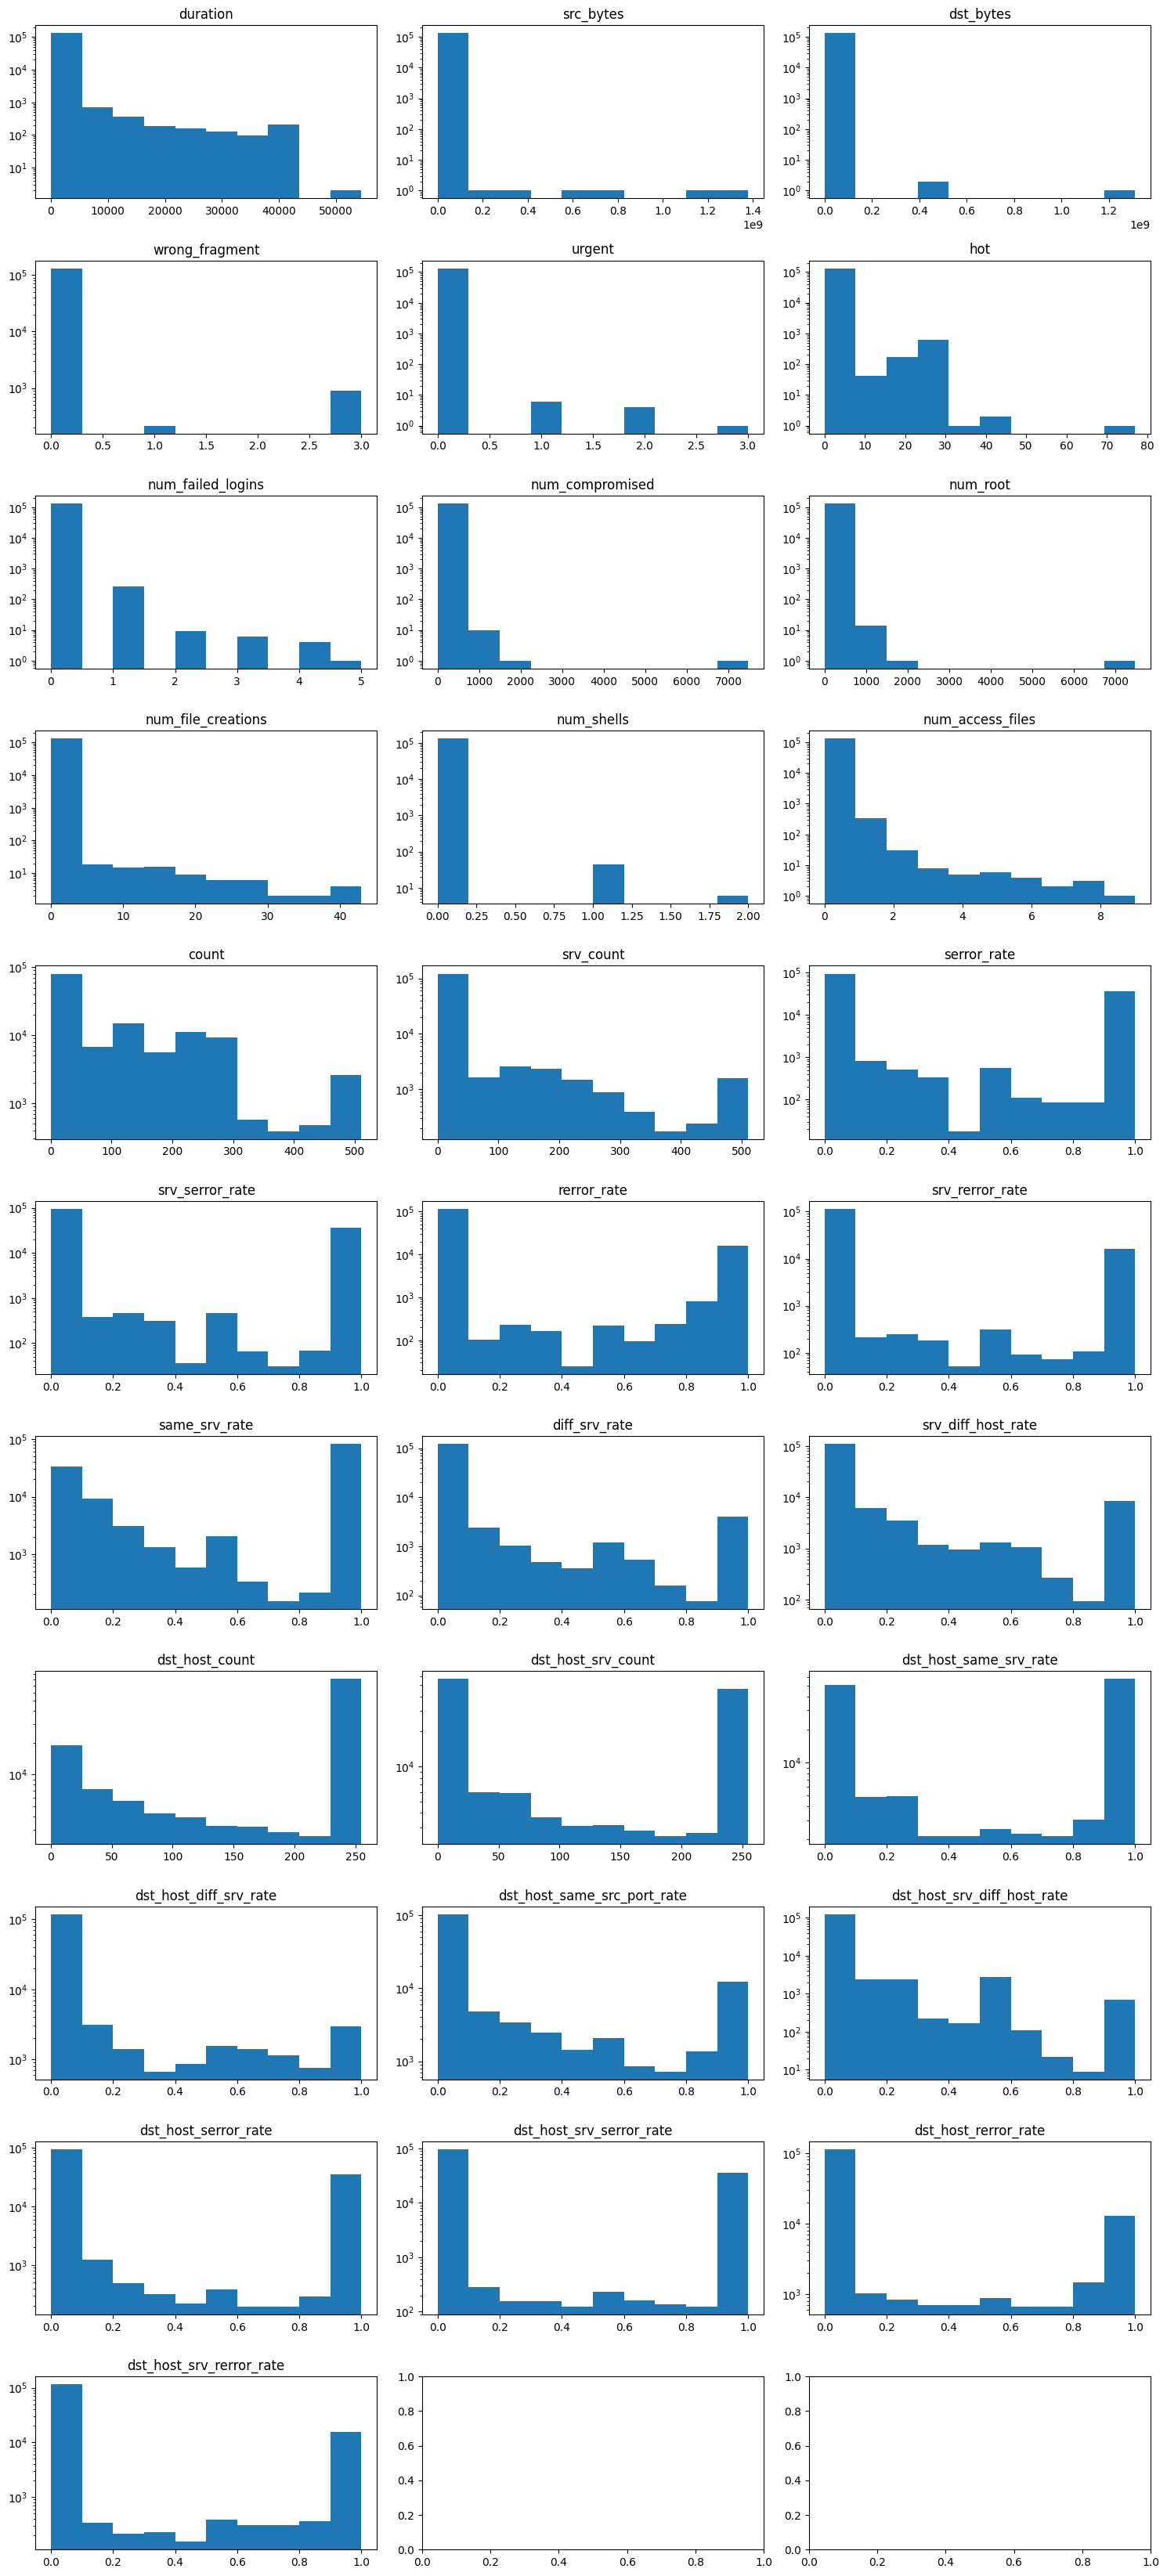

In [20]:
fig, axes = plt.subplots(11, 3, figsize=(15, 33))
for i, feature in enumerate(numerical_features):
  ax = axes.flat[i]
  ax.set_title(feature)
  ax.hist(df[feature])
  ax.set_yscale('log')
plt.tight_layout()
plt.show()

In [21]:
# Which features differ most between Normal and Attack samples?
normal_median_statisitcs = df[df['label'] == 0][numerical_features].median()
attack_median_statisitcs = df[df['label'] == 1][numerical_features].median()
Q1 = df[numerical_features].quantile(0.25)
Q3 = df[numerical_features].quantile(0.75)
IQR = Q3 - Q1
exclude_numerical_features = IQR[IQR == 0].index
normal_median_statisitcs = normal_median_statisitcs.drop(index = exclude_numerical_features)
attack_median_statisitcs = attack_median_statisitcs.drop(index = exclude_numerical_features)
IQR = IQR[IQR != 0]
diff_median_statisitcs = (normal_median_statisitcs - attack_median_statisitcs).abs()/IQR
diff_median_statisitcs.sort_values(ascending=False).head(10)

,0
same_srv_rate,1.011111
diff_srv_rate,1.000000
serror_rate,1.000000
srv_serror_rate,1.000000
dst_host_srv_serror_rate,1.000000
dst_host_serror_rate,1.000000
dst_host_same_srv_rate,1.000000
dst_host_diff_srv_rate,1.000000
dst_host_srv_count,0.991803
count,0.942857


In [22]:
# Which features differ most between DoS, Probe, R2L, and U2R?
df_attacks = df[df['major_cat']!='normal']
major_cat_median = df_attacks.groupby('major_cat')[numerical_features].median()
Q1 = df_attacks[numerical_features].quantile(0.25)
Q3 = df_attacks[numerical_features].quantile(0.75)
IQR = Q3 - Q1
exclude_numerical_features = IQR[IQR == 0].index
major_cat_median = major_cat_median.drop(columns= exclude_numerical_features)
IQR = IQR[IQR != 0]
major_cat_diff = major_cat_median.std() / IQR
major_cat_diff.sort_values(ascending=False)

,0
dst_host_same_src_port_rate,23.700826
dst_host_same_srv_rate,6.066419
dst_host_diff_srv_rate,4.184407
dst_host_srv_count,1.025774
dst_host_rerror_rate,1.000000
diff_srv_rate,1.000000
same_srv_rate,0.560241
serror_rate,0.500000
srv_serror_rate,0.500000
dst_host_serror_rate,0.500000


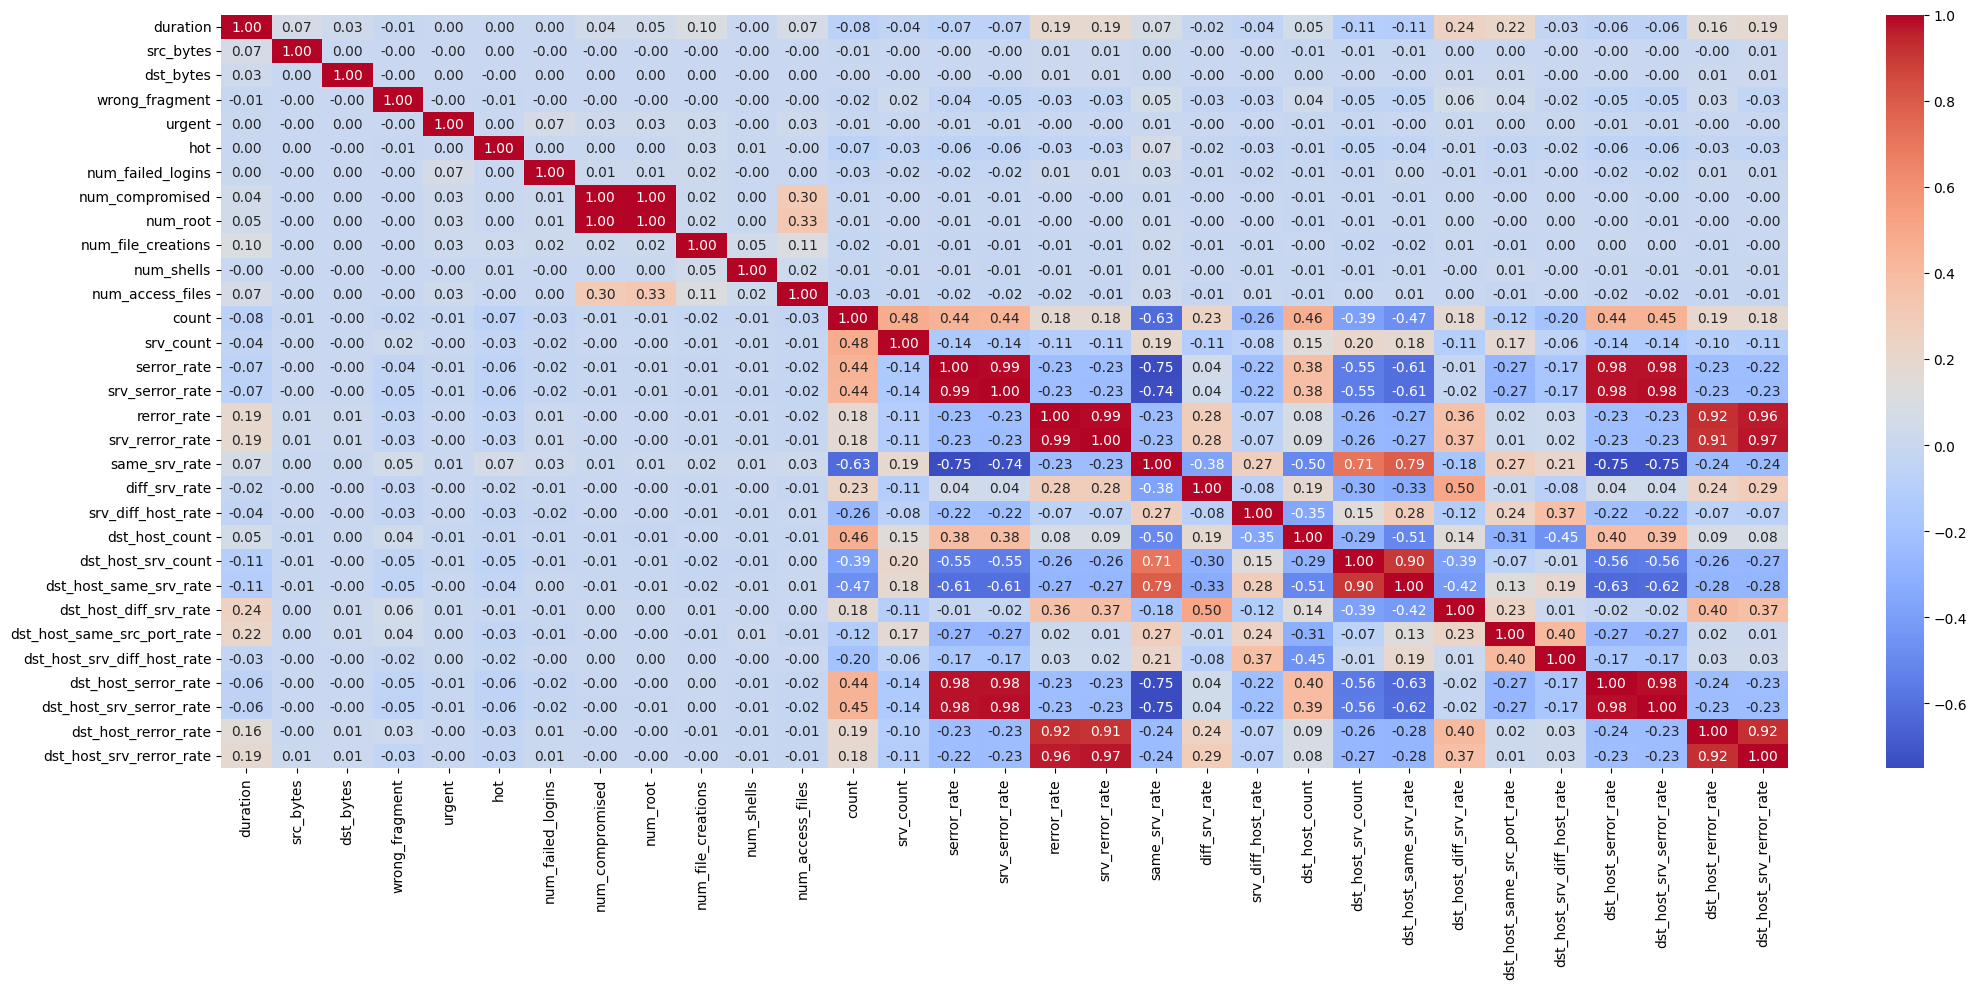

In [23]:
# Which numerical features are highly correlated with each other?
numerical_features_corr = df[numerical_features].corr()
plt.figure(figsize=(22, 10))
sns.heatmap(numerical_features_corr, cmap='coolwarm', annot=True, fmt='0.2f')
plt.tight_layout()
plt.show()

In [24]:
features_highly_corrlated = {}
for feature in numerical_features:
  numerical_features_highly_corrlated = numerical_features_corr[feature][(numerical_features_corr[feature] != 1) & (abs(numerical_features_corr[feature]) > 0.9)]
  features_highly_corrlated[feature]= numerical_features_highly_corrlated.index.to_list()
for feature in features_highly_corrlated.keys():
  print(feature, features_highly_corrlated[feature])
print("""
Two groups of features are highly correlated (>0.9) with each other:
Group 1 (SYN error rate family):
  serror_rate, srv_serror_rate, dst_host_serror_rate, dst_host_srv_serror_rate
Group 2 (REJ error rate family):
  rerror_rate, srv_rerror_rate, dst_host_rerror_rate, dst_host_srv_rerror_rate
Additionally:
  num_compromised is highly correlated with num_root
""")

duration []
src_bytes []
dst_bytes []
wrong_fragment []
urgent []
hot []
num_failed_logins []
num_compromised ['num_root']
num_root ['num_compromised']
num_file_creations []
num_shells []
num_access_files []
count []
srv_count []
serror_rate ['srv_serror_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate']
srv_serror_rate ['serror_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate']
rerror_rate ['srv_rerror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']
srv_rerror_rate ['rerror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']
same_srv_rate []
diff_srv_rate []
srv_diff_host_rate []
dst_host_count []
dst_host_srv_count []
dst_host_same_srv_rate []
dst_host_diff_srv_rate []
dst_host_same_src_port_rate []
dst_host_srv_diff_host_rate []
dst_host_serror_rate ['serror_rate', 'srv_serror_rate', 'dst_host_srv_serror_rate']
dst_host_srv_serror_rate ['serror_rate', 'srv_serror_rate', 'dst_host_serror_rate']
dst_host_rerror_rate ['rerror_rate', 'srv_rerror_rate', 

In [25]:
# Are there highly correlated/redundant features?
print("Yes")

Yes


## Target vs features

- Which features are most associated with the binary target (Normal vs Attack)?
- Which features differ significantly between the major attack categories?
- Are there features that almost perfectly separate certain attack classes?
- Are any features potentially causing data leakage?

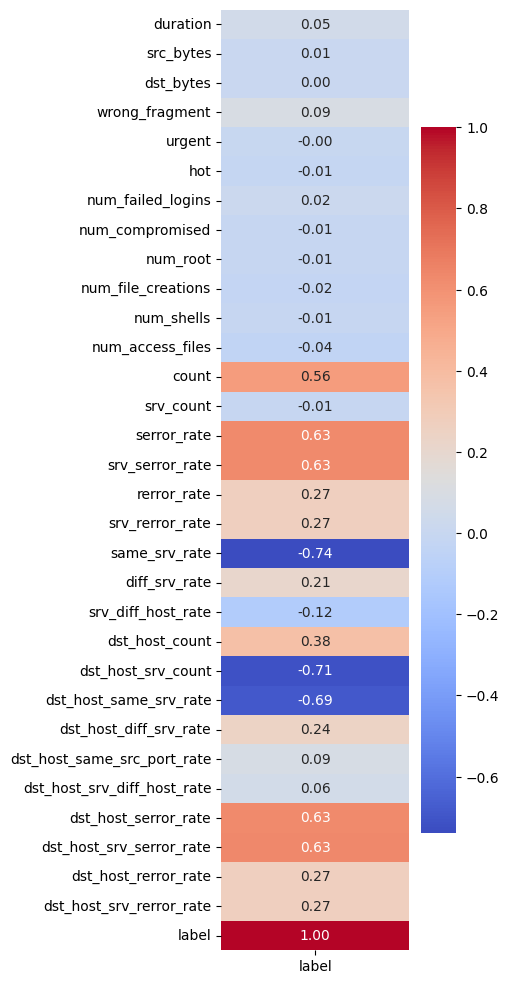

In [26]:
# Which features are most associated with the binary target (Normal vs Attack)?

# numerical features
numerical_features_corr = df[numerical_features + ['label']].corr()[['label']]
plt.figure(figsize=(5, 10))
sns.heatmap(numerical_features_corr, cmap='coolwarm', annot=True, fmt='0.2f')
plt.tight_layout()
plt.show()

In [27]:
# categorical features
clean_categorical_features = [feature for feature in categorical_features if feature not in ['labels', 'major_cat']]
for feature in clean_categorical_features:
  print(feature)
  print(df.groupby('label')[feature].value_counts(normalize = True).groupby(level = 0).head(3) * 100)
  print('-----------')

print("""
we can conclude that these features can be useful to differ between attack and normal flow since it is more associated to one of both:
numerical features
- these feature associated to attacks
  - count
  - serror_rate
  - srv_serror_rate
  - dst_host_serror_rate
  - dst_host_srv_serror_rate
- these feature associated to normal
  - same_srv_rate
  - dst_host_srv_count
  - dst_host_same_srv_rate
categorical features
- service: normal favors http/domain_u/smtp; attacks favor private/eco_i/ecr_i
- flag: normal is dominated by SF (successful); attacks show far more S0 (failed) and REJ
- protocol_type: less differentiating — both classes are TCP-dominated
""")

protocol_type
label  protocol_type
0.0    tcp              79.608875
       udp              18.488124
       icmp              1.903001
1.0    tcp              84.039349
       icmp             11.466611
       udp               4.494040
Name: proportion, dtype: float64
-----------
service
label  service 
0.0    http        56.973403
       domain_u    13.249893
       smtp        10.264543
1.0    private     35.253781
       eco_i        6.624904
       ecr_i        4.828890
Name: proportion, dtype: float64
-----------
flag
label  flag
0.0    SF      94.343621
       REJ      3.844403
       S1       0.516285
1.0    S0      56.243591
       SF      20.927326
       REJ     15.457575
Name: proportion, dtype: float64
-----------

we can conclude that these features can be useful to differ between attack and normal flow since it is more associated to one of both:
numerical features
- these feature associated to attacks
  - count
  - serror_rate
  - srv_serror_rate
  - dst_host_serror_ra

In [28]:
# Which features differ significantly between the major attack categories?
# numerical features
df_attacks = df[df['major_cat']!='normal']
major_cat_median = df_attacks.groupby('major_cat')[numerical_features].median()
Q1 = df_attacks[numerical_features].quantile(0.25)
Q3 = df_attacks[numerical_features].quantile(0.75)
IQR = Q3 - Q1
exclude_numerical_features = IQR[IQR == 0].index
major_cat_median = major_cat_median.drop(columns= exclude_numerical_features)
IQR = IQR[IQR != 0]
major_cat_diff = major_cat_median.std() / IQR
print(major_cat_diff.sort_values(ascending=False))
print('-------------')
print(df.groupby('major_cat')['dst_host_same_src_port_rate'].median())
print('Probe has the highest dst_host_same_src_port_rate value')
print('-------------------------------------------------------')
# categorical features
clean_categorical_features = [feature for feature in categorical_features if feature not in ['labels', 'major_cat']]
for feature in clean_categorical_features:
  print(feature)
  print(df.groupby('major_cat')[feature].value_counts(normalize = True).groupby(level = 0).head(3) * 100)
  print('-----------')

dst_host_same_src_port_rate    23.700826
dst_host_same_srv_rate          6.066419
dst_host_diff_srv_rate          4.184407
dst_host_srv_count              1.025774
dst_host_rerror_rate            1.000000
diff_srv_rate                   1.000000
same_srv_rate                   0.560241
serror_rate                     0.500000
srv_serror_rate                 0.500000
dst_host_serror_rate            0.500000
dst_host_srv_serror_rate        0.500000
count                           0.397619
srv_count                       0.346876
dtype: float64
-------------
major_cat
Dos       0.00
Probe     1.00
R2L       0.01
U2R       0.20
normal    0.01
Name: dst_host_same_src_port_rate, dtype: float64
Probe has the highest dst_host_same_src_port_rate value
-------------------------------------------------------
protocol_type
major_cat  protocol_type
Dos        tcp              91.954166
           icmp              6.182544
           udp               1.863289
Probe      tcp              51.964748


In [29]:
 # Are there features that almost perfectly separate certain attack classes?
print("""
Yes. Examples:
 - dst_host_same_src_port_rate near-perfectly isolates Probe: median 1.00 vs ~0.00-0.01 for Dos/R2L/normal, 0.20 for U2R
 - service='telnet' is highly concentrated in U2R (63%).
 - service='ftp_data'/'ftp' are concentrated in R2L (~65% combined).
 - flag='S0' strongly distinguishes Dos (72.5%) from other categories.
""")
# Are any features potentially causing data leakage?
print("""
Not leakage in the strict sense (no feature directly encodes the label). However,
dst_host_same_src_port_rate near-perfectly isolating Probe is a risk worth flagging:
since NSL-KDD is a synthetically generated dataset, this clean separation may be a
dataset artifact rather than a robust real-world signal, so a model could over-rely
on it in a way that doesn't generalize.
""")


Yes. Examples:
- dst_host_same_src_port_rate near-perfectly isolates Probe: median 1.00 vs ~0.00-0.01 for Dos/R2L/normal, 0.20 for U2R
- service='telnet' is highly concentrated in U2R (63%).
- service='ftp_data'/'ftp' are concentrated in R2L (~65% combined).
- flag='S0' strongly distinguishes Dos (72.5%) from other categories.


Not leakage in the strict sense (no feature directly encodes the label). However,
dst_host_same_src_port_rate near-perfectly isolating Probe is a risk worth flagging:
since NSL-KDD is a synthetically generated dataset, this clean separation may be a
dataset artifact rather than a robust real-world signal, so a model could over-rely
on it in a way that doesn't generalize.



## Attack behavior

- Which attacks have the highest average/median duration?
- Which attacks generate the highest/lowest traffic volume?
- Which attacks have the highest packet rates?
- Which attacks use the most/least common services?
- Which attacks are associated with unusual ports?
- Which attacks have distinctive TCP flag patterns?
- Which attacks show unusual source/destination behavior?

## Protocol / service / flag analysis
- What is the distribution of protocols across Normal and Attack traffic?
- What is the distribution of services across Normal and Attack traffic?
- What is the distribution of flags across Normal and Attack traffic?
- Which protocol-service combinations are most common?
- Which protocol-service combinations are strongly associated with particular attacks?
- Are there categorical values that occur almost exclusively in one class?

## Relationships between variables

- Which numerical features have the strongest positive/negative correlations?
- Are there groups of highly correlated features?
- Do attack categories form distinguishable clusters?
- How do important numerical features change across attack categories?
- Are relationships different for Normal vs Attack traffic?

## Data quality / ML preparation
- Are there invalid or impossible values?
- Are there negative values where they shouldn't exist?
- Are there infinite values?
- Are there suspiciously high values?
- Are train and test sets distributed similarly?
- Do all attack classes appear in both train and test?
- Are there duplicate or near-duplicate samples across train and test?
- Is there potential train/test leakage?

# Preprocessing

## Drop the redundant features that have high corelated to each other

In [30]:
dropped_numerical_features = ['srv_serror_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'srv_rerror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'num_compromised']
df = df.drop(columns = dropped_numerical_features)
numerical_features = [feature for feature in numerical_features if feature not in dropped_numerical_features]
print(df.shape)
print(len(numerical_features))

(132726, 36)
24


## Split data into feature and output

In [31]:
X = df.drop(columns=['label', 'labels', 'major_cat'])
y = df[['label', 'labels', 'major_cat']]
print(X.shape)
print(y.shape)

(132726, 33)
(132726, 3)


## Split features data into training and testing

In [32]:
from sklearn.model_selection import train_test_split
X_training, X_testing, y_training, y_testing = train_test_split(X, y['label'], test_size= 0.2, random_state=42, stratify=y['label'])
print(X_training.shape)
print(X_testing.shape)
print(y_training.shape)
print(y_testing.shape)

(106180, 33)
(26546, 33)
(106180,)
(26546,)


## Encoding categorical features

In [33]:
from sklearn.preprocessing import OneHotEncoder
clean_categorical_features = ['protocol_type', 'service', 'flag']
feature_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

X_training_encoded = feature_encoder.fit_transform(X_training[clean_categorical_features])
X_testing_encoded = feature_encoder.transform(X_testing[clean_categorical_features])

columns_name = feature_encoder.get_feature_names_out()

X_training_encoded = pd.DataFrame(X_training_encoded, columns=columns_name, index = X_training.index)
X_testing_encoded = pd.DataFrame(X_testing_encoded, columns=columns_name, index = X_testing.index)

X_training = X_training.drop(columns=clean_categorical_features)
X_testing = X_testing.drop(columns=clean_categorical_features)

X_training = pd.concat([X_training, X_training_encoded], axis=1)
X_testing = pd.concat([X_testing, X_testing_encoded], axis=1)

print(X_training.shape)
print(X_testing.shape)

(106180, 113)
(26546, 113)


## Normalization

In [34]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_training[numerical_features] = scaler.fit_transform(X_training[numerical_features])
X_testing[numerical_features] = scaler.transform(X_testing[numerical_features])

# Build Detection Model

In [35]:
from xgboost import XGBClassifier
model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

In [36]:
model.fit(X_training, y_training)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=-1,
              num_parallel_tree=None, ...)

In [37]:
from sklearn.metrics import accuracy_score, classification_report
y_pred = model.predict(X_testing)
print(accuracy_score(y_testing, y_pred))
print(classification_report(y_testing, y_pred))

0.9978904543057334
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     14062
         1.0       1.00      1.00      1.00     12484

    accuracy                           1.00     26546
   macro avg       1.00      1.00      1.00     26546
weighted avg       1.00      1.00      1.00     26546



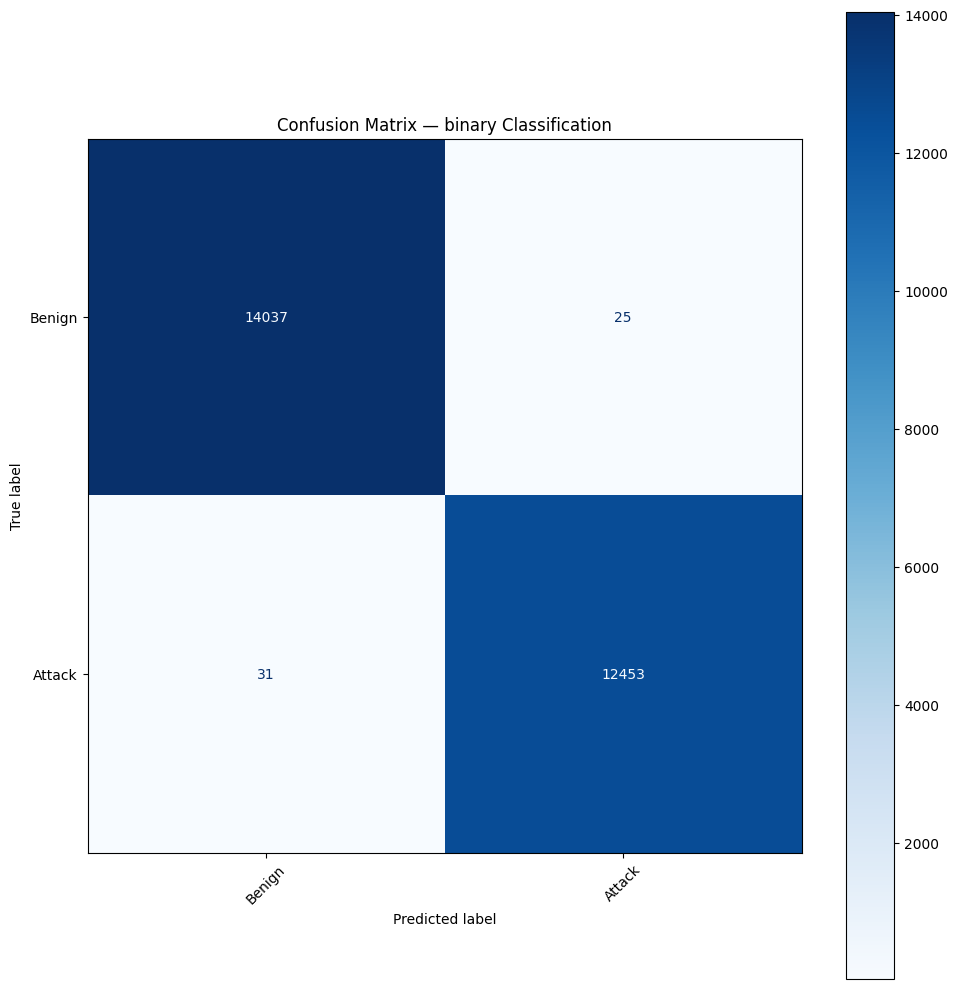

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_testing, y_pred)
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Attack'])
disp.plot(cmap='Blues', values_format='d', ax=ax, xticks_rotation=45)
plt.title('Confusion Matrix — binary Classification')
plt.tight_layout()
plt.show()

# Preprocessing

## Split data into feature and output

In [39]:
df_copy = df[df['major_cat'] != 'normal']
X2 = df_copy.drop(columns=['label', 'labels', 'major_cat'])
y2 = df_copy[['label', 'labels', 'major_cat']]
print(X2.shape)
print(y2.shape)

(62416, 33)
(62416, 3)


## Split features data into training and testing

In [40]:
from sklearn.model_selection import train_test_split
X_training2, X_testing2, y_training2, y_testing2 = train_test_split(X2, y2['major_cat'], test_size= 0.2, random_state=42, stratify=y2['major_cat'])
print(X_training2.shape)
print(X_testing2.shape)
print(y_training2.shape)
print(y_testing2.shape)

(49932, 33)
(12484, 33)
(49932,)
(12484,)


## Encoding categorical features

In [41]:
from sklearn.preprocessing import OneHotEncoder
clean_categorical_features = ['protocol_type', 'service', 'flag']
feature_encoder2 = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

X_training_encoded2 = feature_encoder2.fit_transform(X_training2[clean_categorical_features])
X_testing_encoded2 = feature_encoder2.transform(X_testing2[clean_categorical_features])

columns_name = feature_encoder2.get_feature_names_out()

X_training_encoded2 = pd.DataFrame(X_training_encoded2, columns=columns_name, index = X_training2.index)
X_testing_encoded2 = pd.DataFrame(X_testing_encoded2, columns=columns_name, index = X_testing2.index)

X_training2 = X_training2.drop(columns=clean_categorical_features)
X_testing2 = X_testing2.drop(columns=clean_categorical_features)

X_training2 = pd.concat([X_training2, X_training_encoded2], axis=1)
X_testing2 = pd.concat([X_testing2, X_testing_encoded2], axis=1)

print(X_training2.shape)
print(X_testing2.shape)

(49932, 109)
(12484, 109)


## Encoding output label

In [42]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_training2 = label_encoder.fit_transform(y_training2)
y_testing2 = label_encoder.transform(y_testing2)

## Normalization

In [43]:
from sklearn.preprocessing import RobustScaler
scaler2 = RobustScaler()
X_training2[numerical_features] = scaler2.fit_transform(X_training2[numerical_features])
X_testing2[numerical_features] = scaler2.transform(X_testing2[numerical_features])

# Build major_cat Model

In [44]:
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_training2)

In [45]:
from xgboost import XGBClassifier
model2 = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=4,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

In [46]:
model2.fit(X_training2, y_training2, sample_weight=sample_weights)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=-1, num_class=4, ...)

In [47]:
from sklearn.metrics import accuracy_score, classification_report
y_pred2 = model2.predict(X_testing2)
print(accuracy_score(y_testing2, y_pred2))
print(classification_report(y_testing2, y_pred2))

0.9998397949375201
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9618
           1       1.00      1.00      1.00      2474
           2       1.00      1.00      1.00       376
           3       1.00      1.00      1.00        16

    accuracy                           1.00     12484
   macro avg       1.00      1.00      1.00     12484
weighted avg       1.00      1.00      1.00     12484



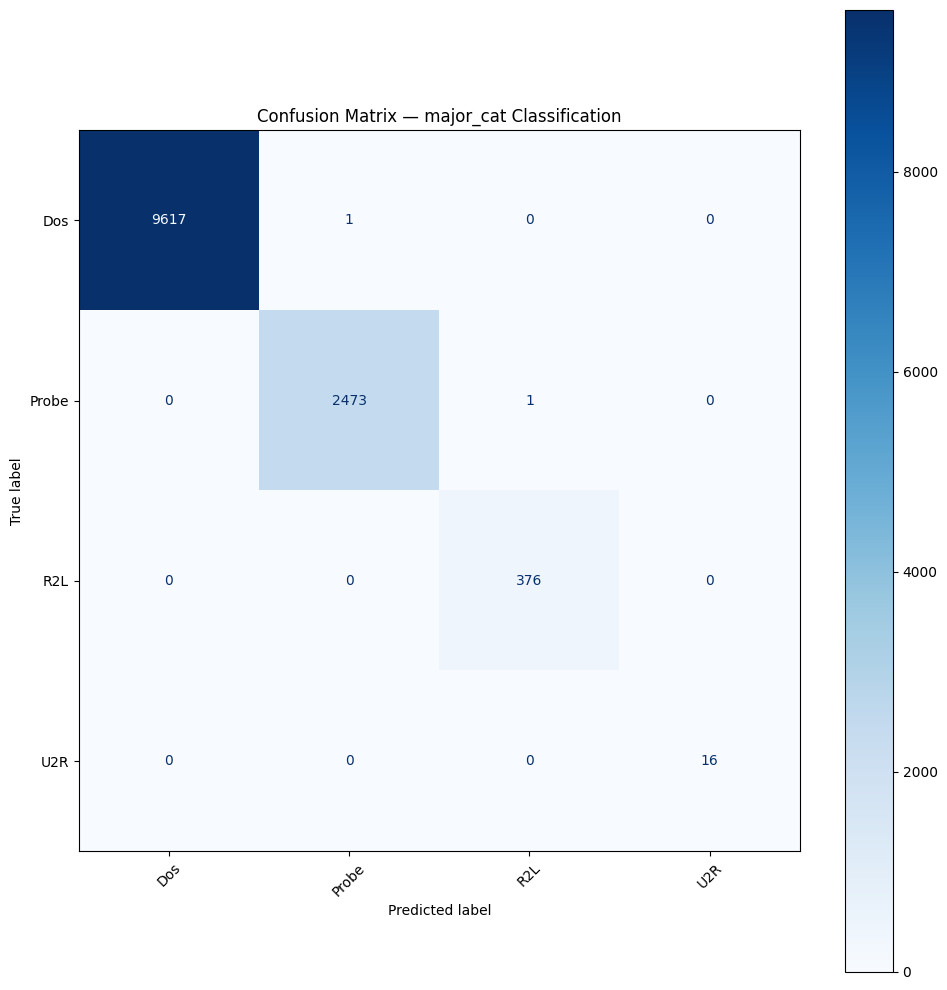

In [50]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm2 = confusion_matrix(y_testing2, y_pred2)
labels = label_encoder.classes_
fig, ax = plt.subplots(figsize=(10, 10))
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=labels)
disp2.plot(cmap='Blues', values_format='d', ax=ax, xticks_rotation=45)
plt.title('Confusion Matrix — major_cat Classification')
plt.tight_layout()
plt.show()

# Preprocessing

## Split data into feature and output

In [51]:
df_copy = df[df['labels'] != 'normal']

labels_count =  df_copy['labels'].value_counts()
labels_count = labels_count[labels_count == 1]
print(labels_count)
print("stratify needs at least two samples to work so we will drop the record of xsnoop")
df_copy = df_copy[df_copy['labels'] != 'xsnoop']

X3 = df_copy.drop(columns=['label', 'labels', 'major_cat'])
y3 = df_copy[['label', 'labels', 'major_cat']]
print(X3.shape)
print(y3.shape)

labels
xsnoop    1
Name: count, dtype: int64
stratify needs at least two samples to work so we will drop the record of xsnoop
(62415, 33)
(62415, 3)


## Split features data into training and testing

In [52]:
from sklearn.model_selection import train_test_split
X_training3, X_testing3, y_training3, y_testing3 = train_test_split(X3, y3['labels'], test_size= 0.2, random_state=42, stratify=y3['labels'])
print(X_training3.shape)
print(X_testing3.shape)
print(y_training3.shape)
print(y_testing3.shape)

(49932, 33)
(12483, 33)
(49932,)
(12483,)


## Encoding categorical features

In [53]:
from sklearn.preprocessing import OneHotEncoder
clean_categorical_features = ['protocol_type', 'service', 'flag']
feature_encoder3 = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

X_training_encoded3 = feature_encoder3.fit_transform(X_training3[clean_categorical_features])
X_testing_encoded3 = feature_encoder3.transform(X_testing3[clean_categorical_features])

columns_name = feature_encoder3.get_feature_names_out()

X_training_encoded3 = pd.DataFrame(X_training_encoded3, columns=columns_name, index = X_training3.index)
X_testing_encoded3 = pd.DataFrame(X_testing_encoded3, columns=columns_name, index = X_testing3.index)

X_training3 = X_training3.drop(columns=clean_categorical_features)
X_testing3 = X_testing3.drop(columns=clean_categorical_features)

X_training3 = pd.concat([X_training3, X_training_encoded3], axis=1)
X_testing3 = pd.concat([X_testing3, X_testing_encoded3], axis=1)

print(X_training3.shape)
print(X_testing3.shape)

(49932, 110)
(12483, 110)


## Encoding output label

In [54]:
from sklearn.preprocessing import LabelEncoder
label_encoder2 = LabelEncoder()
y_training3 = label_encoder2.fit_transform(y_training3)
y_testing3 = label_encoder2.transform(y_testing3)

In [55]:
print(label_encoder2.classes_)

['apache2' 'back' 'buffer_overflow' 'ftp_write' 'guess_passwd'
 'httptunnel' 'imap' 'ipsweep' 'land' 'loadmodule' 'mailbomb' 'mscan'
 'multihop' 'named' 'neptune' 'nmap' 'perl' 'phf' 'pod' 'portsweep'
 'processtable' 'ps' 'rootkit' 'saint' 'satan' 'sendmail' 'smurf'
 'snmpgetattack' 'snmpguess' 'spy' 'teardrop' 'warezclient' 'warezmaster'
 'xlock' 'xterm']


## Normalization

In [56]:
from sklearn.preprocessing import RobustScaler
scaler3 = RobustScaler()
X_training3[numerical_features] = scaler3.fit_transform(X_training3[numerical_features])
X_testing3[numerical_features] = scaler3.transform(X_testing3[numerical_features])

# Build labels Model

In [57]:
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_training3)

In [58]:
from xgboost import XGBClassifier
model3 = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=len(label_encoder2.classes_),
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

In [59]:
model3.fit(X_training3, y_training3, sample_weight=sample_weights)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=-1, num_class=35, ...)

In [60]:
from sklearn.metrics import accuracy_score, classification_report
y_pred3 = model3.predict(X_testing3)
print(accuracy_score(y_testing3, y_pred3))
print(classification_report(y_testing3, y_pred3))

0.9964752062805415
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        46
           1       1.00      1.00      1.00       211
           2       0.64      0.88      0.74         8
           3       0.67      1.00      0.80         2
           4       0.98      0.99      0.98        91
           5       1.00      1.00      1.00         8
           6       0.67      1.00      0.80         2
           7       0.99      1.00      1.00       723
           8       1.00      1.00      1.00         4
           9       1.00      0.50      0.67         2
          10       1.00      1.00      1.00        19
          11       0.94      0.97      0.95        62
          12       0.50      0.33      0.40         3
          14       1.00      1.00      1.00      8522
          15       1.00      0.98      0.99       304
          16       0.50      1.00      0.67         1
          17       1.00      1.00      1.00         1
        

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


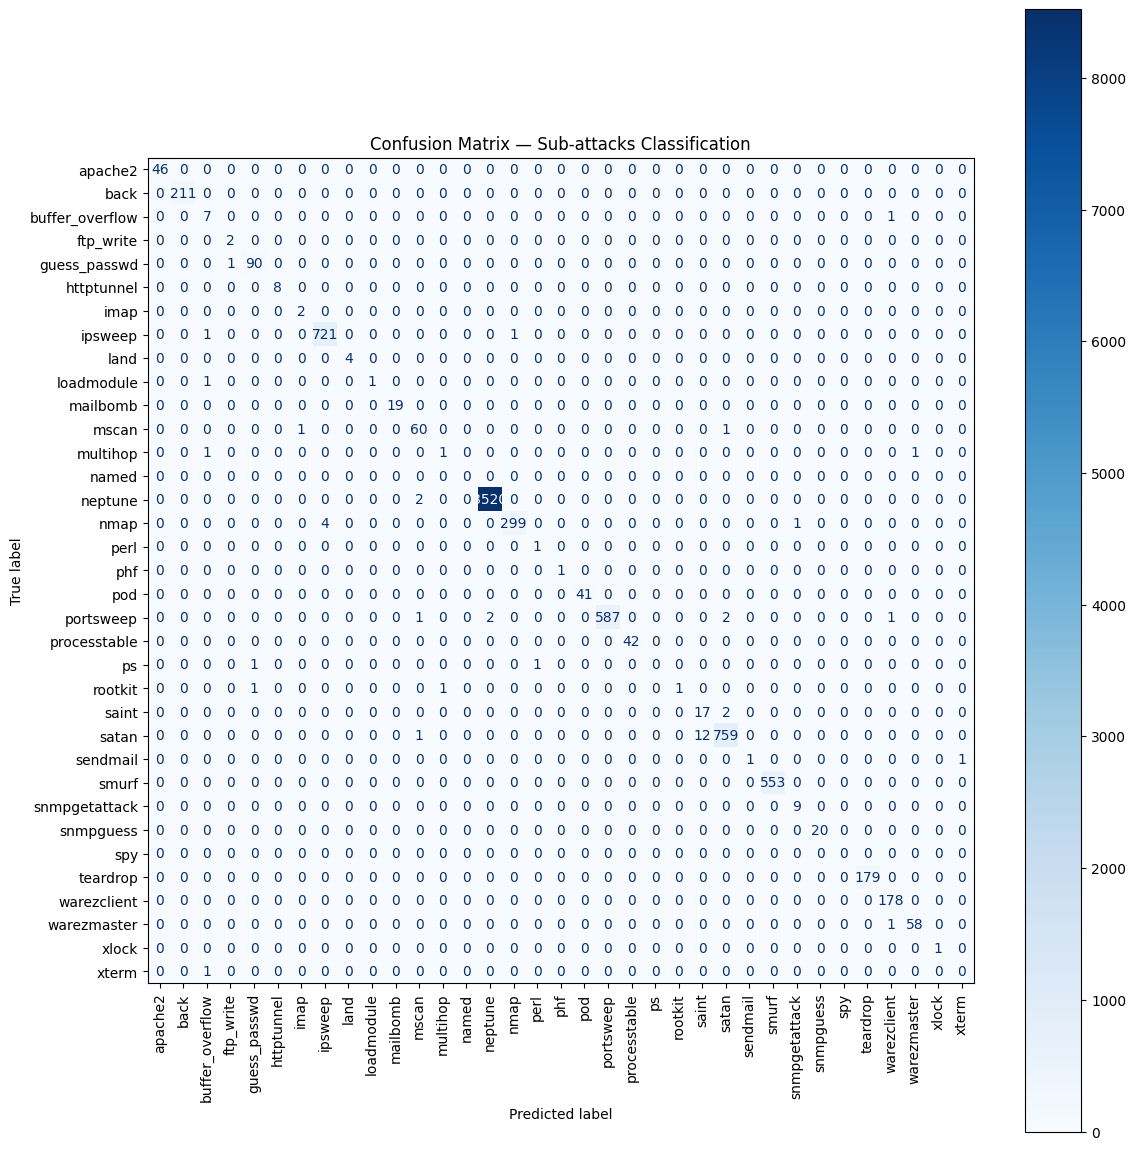

In [71]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
all_class_ids = np.arange(len(label_encoder2.classes_))
cm3 = confusion_matrix(y_testing3, y_pred3, labels=all_class_ids)
labels = label_encoder2.classes_
fig, ax = plt.subplots(figsize=(12, 12))
disp3 = ConfusionMatrixDisplay(confusion_matrix=cm3, display_labels=labels)
disp3.plot(cmap='Blues', values_format='d', ax=ax, xticks_rotation=90, colorbar=True)
plt.title('Confusion Matrix — Sub-attacks Classification')
plt.tight_layout()
plt.show()